In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import transforms, models
from PIL import Image

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
# Custom Dataset class
class DeepLenseDataset(Dataset):
    def __init__(self, data_dir, split='train', categories=['no', 'sphere', 'vort'], augment=False):
        self.data_dir = data_dir
        self.categories = categories
        self.images = []
        self.labels = []
        self.class_to_idx = {cat: idx for idx, cat in enumerate(categories)}
        self.augment = augment
        
        # Data augmentation: random rotations
        if self.augment:
            self.transform = transforms.Compose([
                transforms.RandomRotation(degrees=15),  # Random rotation ±15 degrees
                transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of horizontal flip
                transforms.RandomVerticalFlip(p=0.5),    # 50% chance of vertical flip
            ])
        else:
            self.transform = None
        
        # Load data
        for cat_idx, category in enumerate(categories):
            cat_dir = os.path.join(data_dir, split, category)
            files = sorted([f for f in os.listdir(cat_dir) if f.endswith('.npy')])
            for file in files:
                self.images.append(os.path.join(cat_dir, file))
                self.labels.append(cat_idx)
        
        print(f"Loaded {len(self.images)} images from {split} set (augment={augment})")

    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        # Load image
        img = np.load(img_path).astype(np.float32)
        # Remove channel dimension if needed and add it back with 1 channel
        if img.ndim == 3:
            img = img[0]  # Take first channel
        img = np.expand_dims(img, axis=0)  # Add channel dimension (1, 150, 150)

        # Apply augmentation if enabled
        if self.augment and self.transform is not None:
            # Convert numpy to PIL Image for transforms
            img_pil = Image.fromarray((img[0] * 255).astype(np.uint8))
            img_pil = self.transform(img_pil)
            # Convert back to numpy
            img = np.expand_dims(np.array(img_pil, dtype=np.float32) / 255.0, axis=0)

        # Log Normalization of data
        img = (np.log1p(1000*img)/np.log1p(1000)).astype(np.float32) # log (1 + a*x)/ log (1 + a)
        
        # Convert grayscale to 3 channels for ResNet
        img = np.repeat(img, 3, axis=0)
        
        return torch.from_numpy(img), label

# Create datasets
train_dataset = DeepLenseDataset('dataset', split='train', augment=True)
val_dataset = DeepLenseDataset('dataset', split='val', augment=False)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Loaded 30000 images from train set (augment=True)
Loaded 7500 images from val set (augment=False)
Train batches: 938
Val batches: 235


In [3]:
# Load Pre-trained ResNet Model
# Load ResNet18 with pre-trained weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze early layers (optional) - only fine-tune later layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last residual block and fully connected layer
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace the final fully connected layer for 3-class classification
# ResNet18 has 512 features in the final fc layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

# Move to device
model = model.to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters())} total parameters")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model created with 11178051 total parameters
Trainable parameters: 8395267


In [4]:
# Loss and optimizer
# Compute class weights to balance any class imbalance
from collections import Counter
class_counts = Counter(train_dataset.labels)
total_samples = len(train_dataset)
class_weights = torch.tensor([total_samples / (3 * class_counts[i]) for i in range(3)], dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
# Only optimize trainable parameters
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc="Training")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'Loss': loss.item(), 'Acc': 100 * correct / total})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validating")
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({'Loss': loss.item(), 'Acc': 100 * correct / total})
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

Class weights: tensor([1., 1., 1.], device='mps:0')


In [5]:
# Training loop
num_epochs = 50
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_val_acc = 0
patience_counter = 0
early_stopping_patience = 10

print("Starting training...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc, preds, labels = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_resnet18.pth')
        patience_counter = 0
        print(f"Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1

    # Get predictions on validation set
    _, _, final_preds, final_labels = validate(model, val_loader, criterion, device)

    # Classification report
    categories = ['no', 'sphere', 'vort']
    print("\nClassification Report:")
    print(classification_report(final_labels, final_preds, target_names=categories))
    
    # Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("\nTraining completed!")

# Load best model
model.load_state_dict(torch.load('best_model_resnet18.pth'))
print("Best model loaded.")

Starting training...

Epoch 1/50


Validating: 100%|██████████| 235/235 [00:11<00:00, 19.72it/s, Loss=1.18, Acc=39.6]


Train Loss: 1.0966, Train Acc: 39.17%
Val Loss: 1.1203, Val Acc: 39.61%
Best model saved! Val Acc: 39.61%


Validating: 100%|██████████| 235/235 [00:11<00:00, 21.34it/s, Loss=1.18, Acc=39.6]



Classification Report:
              precision    recall  f1-score   support

          no       0.39      0.88      0.54      2500
      sphere       0.46      0.01      0.02      2500
        vort       0.41      0.29      0.34      2500

    accuracy                           0.40      7500
   macro avg       0.42      0.40      0.30      7500
weighted avg       0.42      0.40      0.30      7500


Epoch 2/50


...


Classification Report:
              precision    recall  f1-score   support

          no       0.59      0.82      0.68      2500
      sphere       0.58      0.47      0.52      2500
        vort       0.67      0.53      0.59      2500

    accuracy                           0.61      7500
   macro avg       0.61      0.61      0.60      7500
weighted avg       0.61      0.61      0.60      7500


Epoch 50/50


Validating: 100%|██████████| 235/235 [00:10<00:00, 21.43it/s, Loss=1.21, Acc=60.8] 


Train Loss: 0.8303, Train Acc: 60.42%
Val Loss: 0.8280, Val Acc: 60.77%


Validating: 100%|██████████| 235/235 [00:10<00:00, 23.09it/s, Loss=1.21, Acc=60.8] 



Classification Report:
              precision    recall  f1-score   support

          no       0.58      0.85      0.69      2500
      sphere       0.58      0.46      0.51      2500
        vort       0.69      0.52      0.59      2500

    accuracy                           0.61      7500
   macro avg       0.62      0.61      0.60      7500
weighted avg       0.62      0.61      0.60      7500


Training completed!
Best model loaded.


In [6]:
# Get final predictions on validation set
_, _, final_preds, final_labels = validate(model, val_loader, criterion, device)

# Classification report
categories = ['no', 'sphere', 'vort']
print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=categories))

# Confusion matrix
cm = confusion_matrix(final_labels, final_preds)
print("\nConfusion Matrix:")
print(cm)

Validating: 100%|██████████| 235/235 [00:11<00:00, 19.80it/s, Loss=0.944, Acc=61.2]


Classification Report:
              precision    recall  f1-score   support

          no       0.60      0.79      0.69      2500
      sphere       0.57      0.50      0.53      2500
        vort       0.67      0.54      0.60      2500

    accuracy                           0.61      7500
   macro avg       0.61      0.61      0.61      7500
weighted avg       0.61      0.61      0.61      7500


Confusion Matrix:
[[1984  339  177]
 [ 760 1257  483]
 [ 542  612 1346]]


In [7]:
# Debug: Check class distribution and predictions
from collections import Counter
true_dist = Counter(final_labels)
pred_dist = Counter(final_preds)

print("\n=== Class Distribution ===")
print(f"True distribution: {dict(true_dist)}")
print(f"Predicted distribution: {dict(pred_dist)}")
print(f"\nCategories mapping: 0=no, 1=sphere, 2=vortex")

# Check if model is confident about predictions
model.eval()
all_confidences = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        max_probs = torch.max(probs, dim=1)[0]
        all_confidences.extend(max_probs.cpu().numpy())

avg_confidence = np.mean(all_confidences)
print(f"\nAverage prediction confidence: {avg_confidence:.4f}")
print(f"Min confidence: {np.min(all_confidences):.4f}, Max: {np.max(all_confidences):.4f}")


=== Class Distribution ===
True distribution: {np.int64(0): 2500, np.int64(1): 2500, np.int64(2): 2500}
Predicted distribution: {np.int64(0): 3286, np.int64(1): 2208, np.int64(2): 2006}

Categories mapping: 0=no, 1=sphere, 2=vortex

Average prediction confidence: 0.6308
Min confidence: 0.3341, Max: 1.0000


In [8]:
# Compute ROC curve and AUC score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get probability predictions
model.eval()
all_probs = []
all_labels_roc = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels_roc.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels_roc = np.array(all_labels_roc)

# Binarize labels for multiclass ROC
num_classes = 3
all_labels_binarized = label_binarize(all_labels_roc, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class (one-vs-rest)
fpr = {}
tpr = {}
roc_auc_per_class = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_binarized[:, i], all_probs[:, i])
    roc_auc_per_class[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr_micro, tpr_micro, _ = roc_curve(all_labels_binarized.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Compute macro-average ROC AUC
roc_auc_macro = np.mean(list(roc_auc_per_class.values()))

print("\n=== ROC Curve and AUC Scores ===")
print(f"AUC (Micro-average): {roc_auc_micro:.4f}")
print(f"AUC (Macro-average): {roc_auc_macro:.4f}")
for i, cat in enumerate(categories):
    print(f"AUC ({cat}): {roc_auc_per_class[i]:.4f}")


=== ROC Curve and AUC Scores ===
AUC (Micro-average): 0.8065
AUC (Macro-average): 0.8009
AUC (no): 0.8572
AUC (sphere): 0.7428
AUC (vort): 0.8027


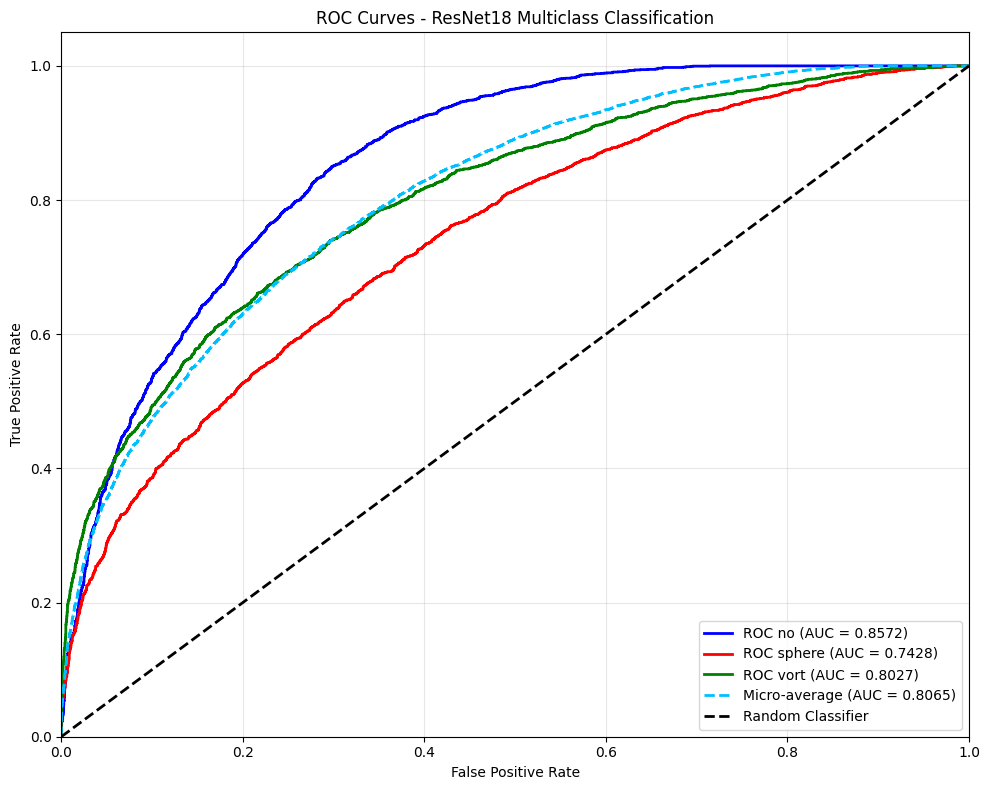

ROC curves saved as 'roc_curves_resnet18.png'


In [9]:
# Plot ROC curves
colors = ['blue', 'red', 'green']
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve for each class
for i, cat in enumerate(categories):
    ax.plot(fpr[i], tpr[i], color=colors[i], lw=2, 
            label=f'ROC {cat} (AUC = {roc_auc_per_class[i]:.4f})')

# Plot micro-average ROC curve
ax.plot(fpr_micro, tpr_micro, color='deepskyblue', linestyle='--', lw=2,
        label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Plot diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - ResNet18 Multiclass Classification')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_resnet18.png', dpi=150)
plt.show()

print("ROC curves saved as 'roc_curves_resnet18.png'")

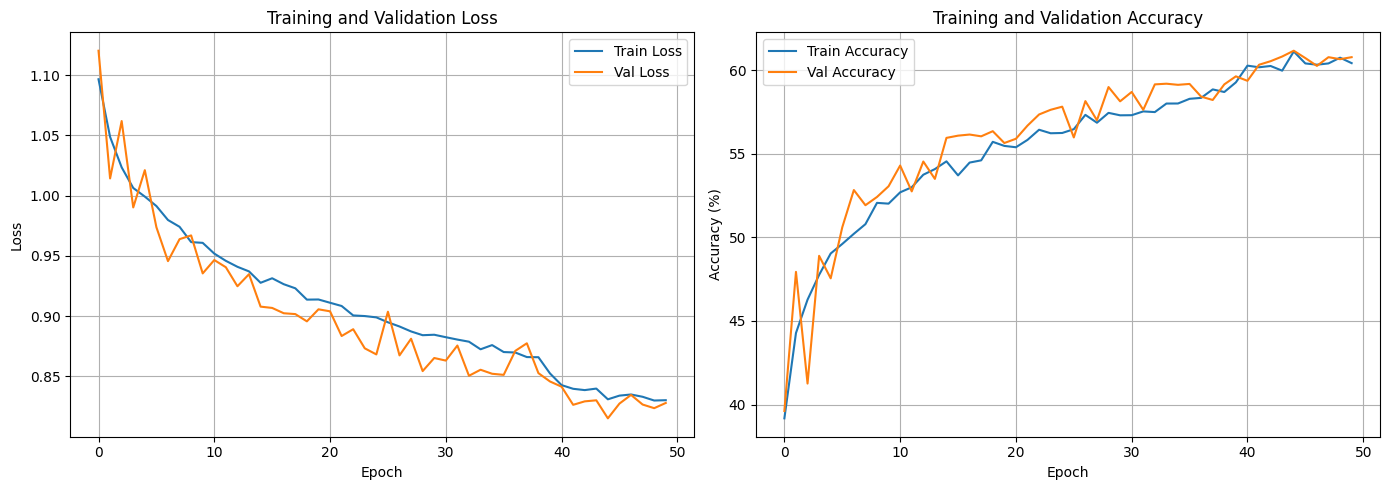

Training curves saved as 'training_curves_resnet18.png'


In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves_resnet18.png')
plt.show()

print("Training curves saved as 'training_curves_resnet18.png'")

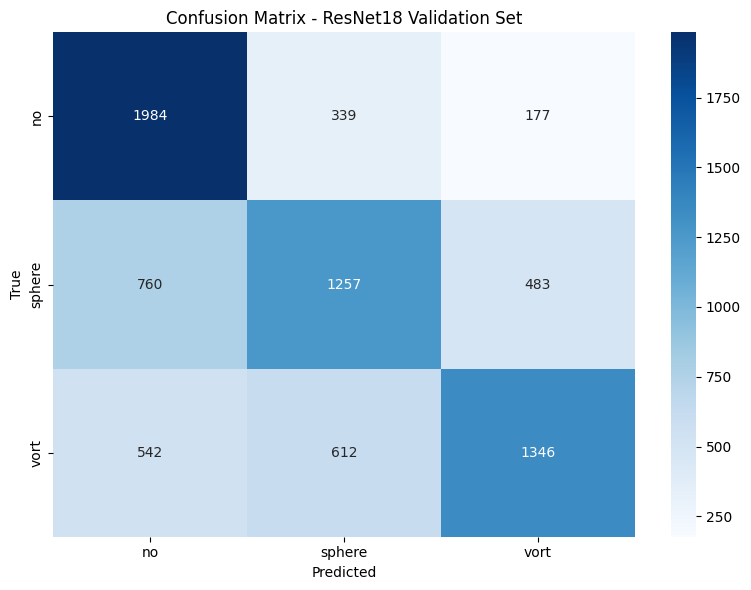

Confusion matrix saved as 'confusion_matrix_resnet18.png'


In [11]:
# Plot confusion matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - ResNet18 Validation Set')
plt.tight_layout()
plt.savefig('confusion_matrix_resnet18.png')
plt.show()

print("Confusion matrix saved as 'confusion_matrix_resnet18.png'")